In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import scipy as sp
import numpy as np
%matplotlib inline

In [5]:
# Draw figures. LinRLog (concordance correlation coefficient) vs Pearson's R
def DrawFiguresLinRvsR(FileName, SheetName, NameForSave):
    df = pd.read_excel(FileName, sheet_name=SheetName, header=0)
    # create the folder
    FolderName = './Figures/LinR vs PearsonR/'
    if not os.path.exists(FolderName):
        os.makedirs(FolderName)
    
    # Draw figures
    g = sns.JointGrid(data=df, x='R Log Mean', y='LinR Log Mean', hue="Type",
                      palette=sns.set_palette(sns.color_palette('Dark2')))
    fig = g.plot(sns.scatterplot, sns.histplot, alpha=.2, edgecolor=".2", linewidth=0)
    fig.plot_marginals(sns.histplot, kde=True)
    fig.ax_joint.set_xlabel('PearsonR', fontweight='bold', fontsize=14)
    fig.ax_joint.set_ylabel('LinR', fontweight='bold', fontsize=14)
    
    # draw y=x
    xlower, xupper = g.ax_joint.get_xlim()
    ylower, yupper = g.ax_joint.get_ylim()
    lims = [max(xlower, ylower), min(xupper, yupper)]
    fig.ax_joint.plot(lims, lims, color=[0.229,0.298,0.754], linestyle='--')
    
    
    
    plt.show()
    SaveFilePdf = FolderName + NameForSave + ' LinR vs PearsonR.pdf'
    SaveFileTif = FolderName + NameForSave + ' LinR vs PearsonR.tif'    
    fig.savefig(SaveFilePdf, format='pdf')
    fig.savefig(SaveFileTif, format='tif', dpi=300, facecolor='white', transparent=False)

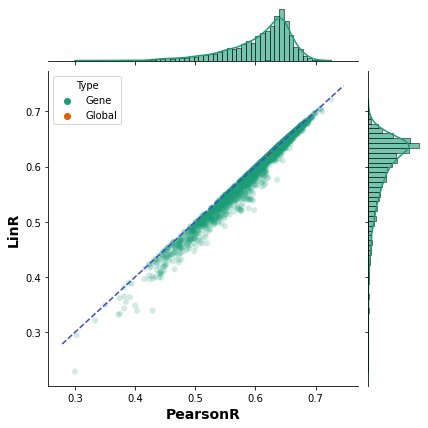

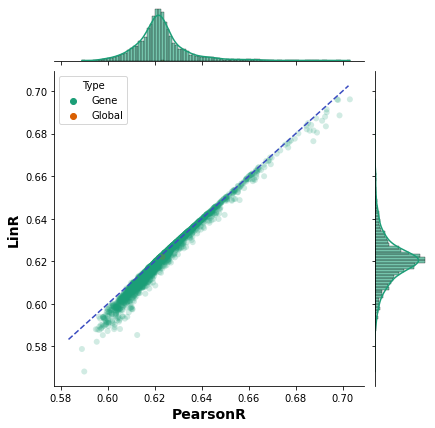

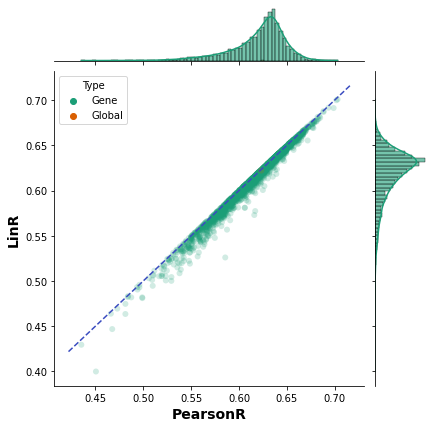

In [6]:
DrawFiguresLinRvsR('./Datasheet/Gene Result.xlsx', 'PFF_Outgoing', 'Outgoing')    
DrawFiguresLinRvsR('./Datasheet/Gene Result.xlsx', 'PFF_Incoming', 'Incoming')   
DrawFiguresLinRvsR('./Datasheet/Gene Result.xlsx', 'PFF_Combined', 'Combined')   